In [9]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

spark = SparkSession.builder \
    .appName("Medallion Architecture") \
    .getOrCreate()

In [10]:
df_bronze = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("large_sales_data.csv")

df_bronze.show(5)

+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|   product|   category|quantity|unit_price|revenue|order_date|     city|region|  sales_rep|  payment_method|order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|    1001|  Sneha Reddy|   Monitor|Electronics|      12|     22000| 264000|2023-05-21|   Mumbai|  West|Meera Patel|             UPI|   Delivered|
|    1002| Ramesh Kumar|   Printer|Electronics|      10|     12000| 120000|2023-08-05|    Delhi| North|Anil Sharma|     Credit Card|     Shipped|
|    1003| Rahul Mishra|     Mouse|Accessories|      10|       800|   8000|2023-01-14|Ahmedabad|  West|Meera Patel|Cash on Delivery|     Shipped|
|    1004|   Suresh Rao|    Tablet|Electronics|       5|     32000| 160000|2023-01-04|    Surat|  West| Ravi Kumar|Cash on D

In [11]:
print(df_bronze.count())

5000


In [12]:
df_silver = df_bronze \
    .dropDuplicates() \
    .dropna(
        subset=[
            'order_id',
            'product',
            'revenue'
        ]
    )

print("Silver Layer Created Successfully!")

Silver Layer Created Successfully!


In [13]:
df_bronze.show(5)

+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|   product|   category|quantity|unit_price|revenue|order_date|     city|region|  sales_rep|  payment_method|order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|    1001|  Sneha Reddy|   Monitor|Electronics|      12|     22000| 264000|2023-05-21|   Mumbai|  West|Meera Patel|             UPI|   Delivered|
|    1002| Ramesh Kumar|   Printer|Electronics|      10|     12000| 120000|2023-08-05|    Delhi| North|Anil Sharma|     Credit Card|     Shipped|
|    1003| Rahul Mishra|     Mouse|Accessories|      10|       800|   8000|2023-01-14|Ahmedabad|  West|Meera Patel|Cash on Delivery|     Shipped|
|    1004|   Suresh Rao|    Tablet|Electronics|       5|     32000| 160000|2023-01-04|    Surat|  West| Ravi Kumar|Cash on D

In [14]:
df_silver = df_bronze \
    .dropDuplicates() \
    .dropna(
        subset=[
            'order_id',
            'product',
            'revenue'
        ]
    )

print("Silver Layer Created Successfully!")

Silver Layer Created Successfully!


In [15]:
df_silver.show(5)

+--------+-------------+--------+-----------+--------+----------+-------+----------+---------+------+-----------+--------------+------------+
|order_id|customer_name| product|   category|quantity|unit_price|revenue|order_date|     city|region|  sales_rep|payment_method|order_status|
+--------+-------------+--------+-----------+--------+----------+-------+----------+---------+------+-----------+--------------+------------+
|    1246|  Divya Singh|Keyboard|Accessories|      11|      1200|  13200|2023-02-07|  Kolkata|  East|Kavya Reddy|   Net Banking|     Shipped|
|    1323|   Ananya Das|  Webcam|Accessories|       7|      2500|  17500|2023-01-24|  Kolkata|  East|Meera Patel|           UPI|   Delivered|
|    1386|Kavya Nambiar| Speaker|Electronics|      13|      4500|  58500|2023-04-16|Bangalore| South|Meera Patel|   Credit Card|  Processing|
|    1939|   Amit Verma|Keyboard|Accessories|       8|      1200|   9600|2023-12-21|  Kolkata|  East| Priya Nair|           UPI|   Delivered|
|    2

In [16]:
print("Bronze Rows :", df_bronze.count())

print("Silver Rows :", df_silver.count())

Bronze Rows : 5000
Silver Rows : 5000


In [17]:
from pyspark.sql.functions import *

df_silver = df_silver.withColumn(
    "order_date",
    to_date(col("order_date"))
)

In [18]:
df_silver = df_silver \
    .withColumn(
        "order_year",
        year(col("order_date"))
    ) \
    .withColumn(
        "order_month",
        month(col("order_date"))
    )

In [20]:
from pyspark.sql.functions import *

In [21]:
print(df_silver.columns)

['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status', 'order_year', 'order_month']


In [22]:
df_silver.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)



In [23]:
print(df_silver.columns)

df_silver.printSchema()

['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status', 'order_year', 'order_month']
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)



In [24]:
from pyspark.sql import functions as F

top_product = df_silver \
    .groupBy("product") \
    .agg(
        F.sum("revenue").alias("total_revenue"),
        F.count("order_id").alias("total_orders"),
        F.countDistinct("customer_name").alias("unique_customers"),
        F.avg("revenue").alias("avg_revenue"),
        F.max("revenue").alias("max_revenue")
    )

top_product.show()

+----------+-------------+------------+----------------+------------------+-----------+
|   product|total_revenue|total_orders|unique_customers|       avg_revenue|max_revenue|
+----------+-------------+------------+----------------+------------------+-----------+
|   Speaker|     16317000|         470|              15| 34717.02127659575|      67500|
|    Webcam|     10982500|         532|              15|20643.796992481202|      37500|
|   USB Hub|      2447400|         527|              15| 4644.022770398482|       9000|
|    Laptop|    182700000|         502|              15|363944.22310756973|     675000|
|     Mouse|      3207200|         492|              15|  6518.69918699187|      12000|
|    Tablet|    135104000|         532|              15| 253954.8872180451|     480000|
|   Printer|     44544000|         488|              15| 91278.68852459016|     180000|
|  Keyboard|      4878000|         495|              15| 9854.545454545454|      18000|
|   Monitor|     82126000|      

In [26]:
top_product.orderBy(
    F.col("total_revenue").desc()
).show()

+----------+-------------+------------+----------------+------------------+-----------+
|   product|total_revenue|total_orders|unique_customers|       avg_revenue|max_revenue|
+----------+-------------+------------+----------------+------------------+-----------+
|    Laptop|    182700000|         502|              15|363944.22310756973|     675000|
|    Tablet|    135104000|         532|              15| 253954.8872180451|     480000|
|   Monitor|     82126000|         481|              15|170740.12474012474|     330000|
|   Printer|     44544000|         488|              15| 91278.68852459016|     180000|
|   Speaker|     16317000|         470|              15| 34717.02127659575|      67500|
|Headphones|     13541500|         481|              15|28152.806652806652|      52500|
|    Webcam|     10982500|         532|              15|20643.796992481202|      37500|
|  Keyboard|      4878000|         495|              15| 9854.545454545454|      18000|
|     Mouse|      3207200|      

In [27]:
print("=" * 60)

print("GOLD LAYER PRODUCT ANALYSIS COMPLETED")

print("=" * 60)

print("Revenue Analysis Completed")

print("Customer Analysis Completed")

print("Product Analysis Completed")

GOLD LAYER PRODUCT ANALYSIS COMPLETED
Revenue Analysis Completed
Customer Analysis Completed
Product Analysis Completed


In [30]:
import os

def get_dir_size(path):
  if os.path.isfile(path):
    return os.path.getsize(path) / 1024
  total = 0
  for dirpath, dirnames, filenames in os.walk(path):
    for f in filenames:
      fp = os.path.join(dirpath, f)
      total += os.path.getsize(fp)
  return total / 1024

df_silver.write \
    .mode('overwrite') \
    .parquet('sales_silver.parquet')

print('Silver Paraquet saved: sales_silver.paraquet')
print(f'Silver size: {get_dir_size("sales_silver.parquet"):.1f} KB')

df_Verify = spark.read.parquet('sales_silver.parquet')
print(f'Verify Silver size: {get_dir_size("sales_silver.parquet"):.1f} KB')
df_Verify

Silver Paraquet saved: sales_silver.paraquet
Silver size: 58.2 KB
Verify Silver size: 58.2 KB


DataFrame[order_id: int, customer_name: string, product: string, category: string, quantity: int, unit_price: int, revenue: int, order_date: date, city: string, region: string, sales_rep: string, payment_method: string, order_status: string, order_year: int, order_month: int]

In [31]:
df_bronze = spark.read \
    .option('header', 'true') \
    .option('inferSchema', 'true') \
    .csv('large_sales_data.csv')

print('=== BRONZE LAYER - Raw Data ==')
print(f'Rows : {df_bronze.count()}')

print(f'Columns: {len(df_bronze.columns)}')
print(f'Column name : {df_bronze.columns}')

df_bronze.printSchema()

=== BRONZE LAYER - Raw Data ==
Rows : 5000
Columns: 13
Column name : ['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [32]:
df_bronze.show(5, truncate=False)

df_bronze.select('quantity', 'unit_price', 'revenue').describe().show()

+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Kumar |Cash on D

In [33]:
df_bronze.write \
    .mode('overwrite') \
    .parquet('sales_bronze.parquet')

print('Bronze Paraquet saved: sales_bronze.paraquet')

Bronze Paraquet saved: sales_bronze.paraquet


In [34]:
df_silver = df_bronze \
    .dropDuplicates() \
    .dropna(subset=['order_id','product','revenue'])

df_silver = df_silver.withColumn('order_date', to_date(col('order_date'), 'yyyy-mm-dd'))

In [35]:
import pyspark.sql.functions as F

df_silver = df_silver \
    .withColumn('order_year', F.year(F.col('order_date'))) \
    .withColumn('order_month', F.month(F.col('order_date')))

df_silver = df_silver.withColumn(
    'revenue_category',
    F.when(F.col('revenue') > 40000, 'High Revenue')
    .when(F.col('revenue') > 10000, 'Medium Revenue')
    .otherwise('Low Revenue')
)

In [37]:
import matplotlib.pyplot as plt

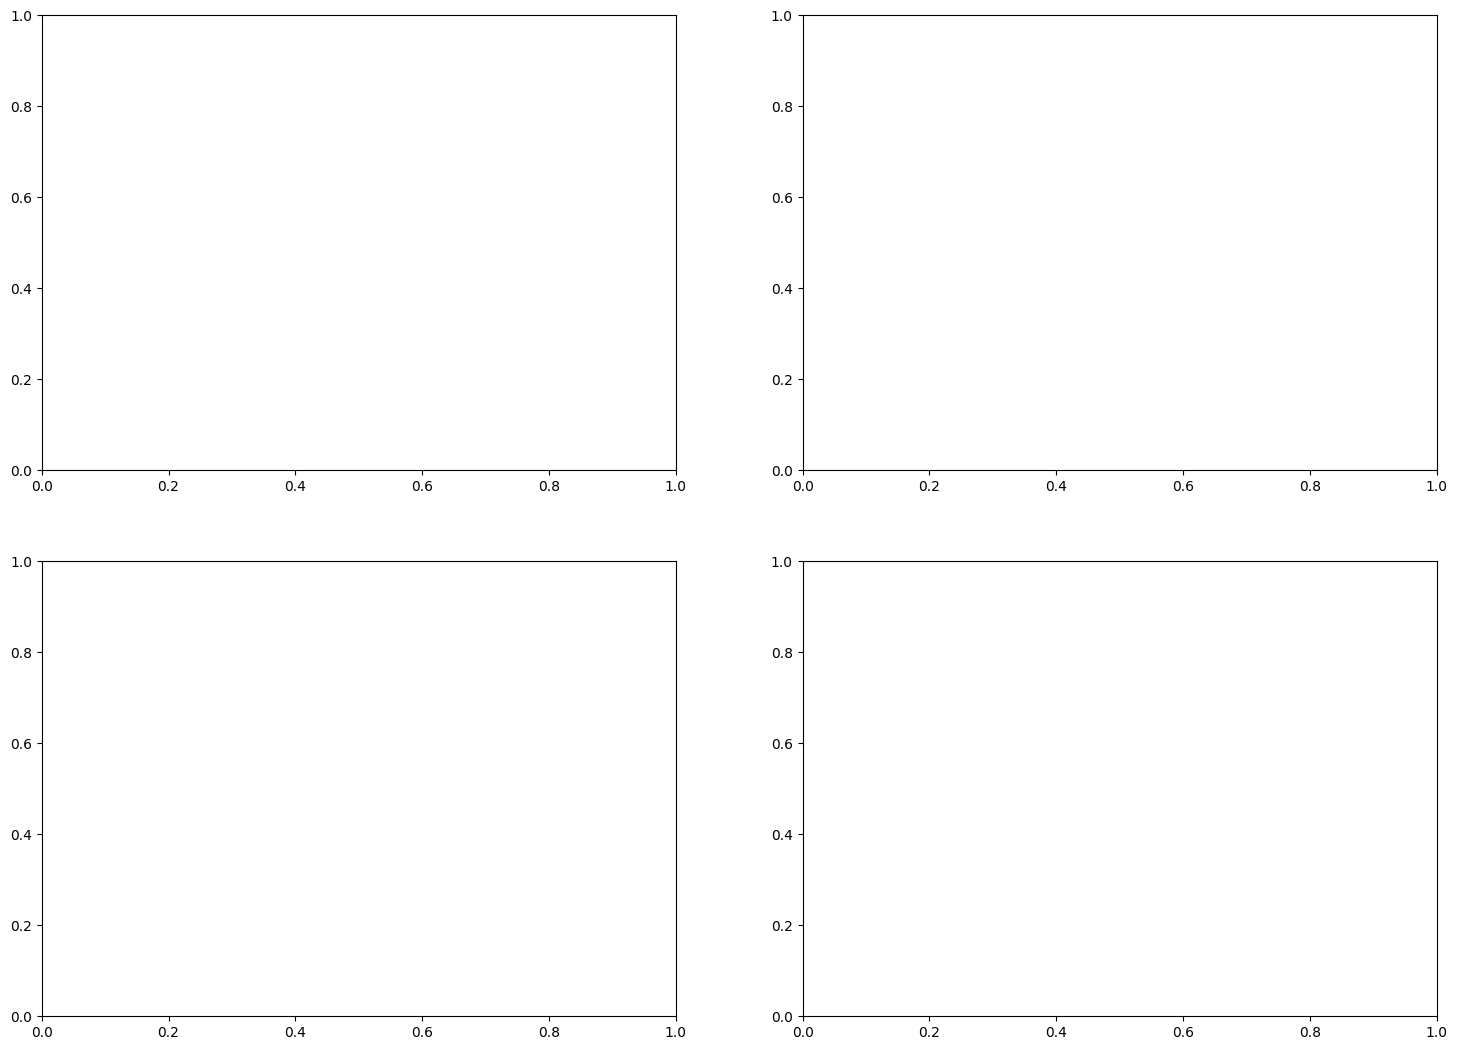

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

In [43]:
print(df_silver.columns)

['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status', 'order_year', 'order_month', 'revenue_category']


In [44]:
from pyspark.sql import functions as F

region_sales = df_silver.groupBy("region") \
    .agg(
        F.sum("revenue").alias("total_revenue")
    )

region_sales.show()

+------+-------------+
|region|total_revenue|
+------+-------------+
| South|    147145900|
|  East|     50547700|
|  West|    198275600|
| North|     99878400|
+------+-------------+



In [45]:
region_pd = region_sales.toPandas()

print(region_pd.head())

  region  total_revenue
0  South      147145900
1   East       50547700
2   West      198275600
3  North       99878400


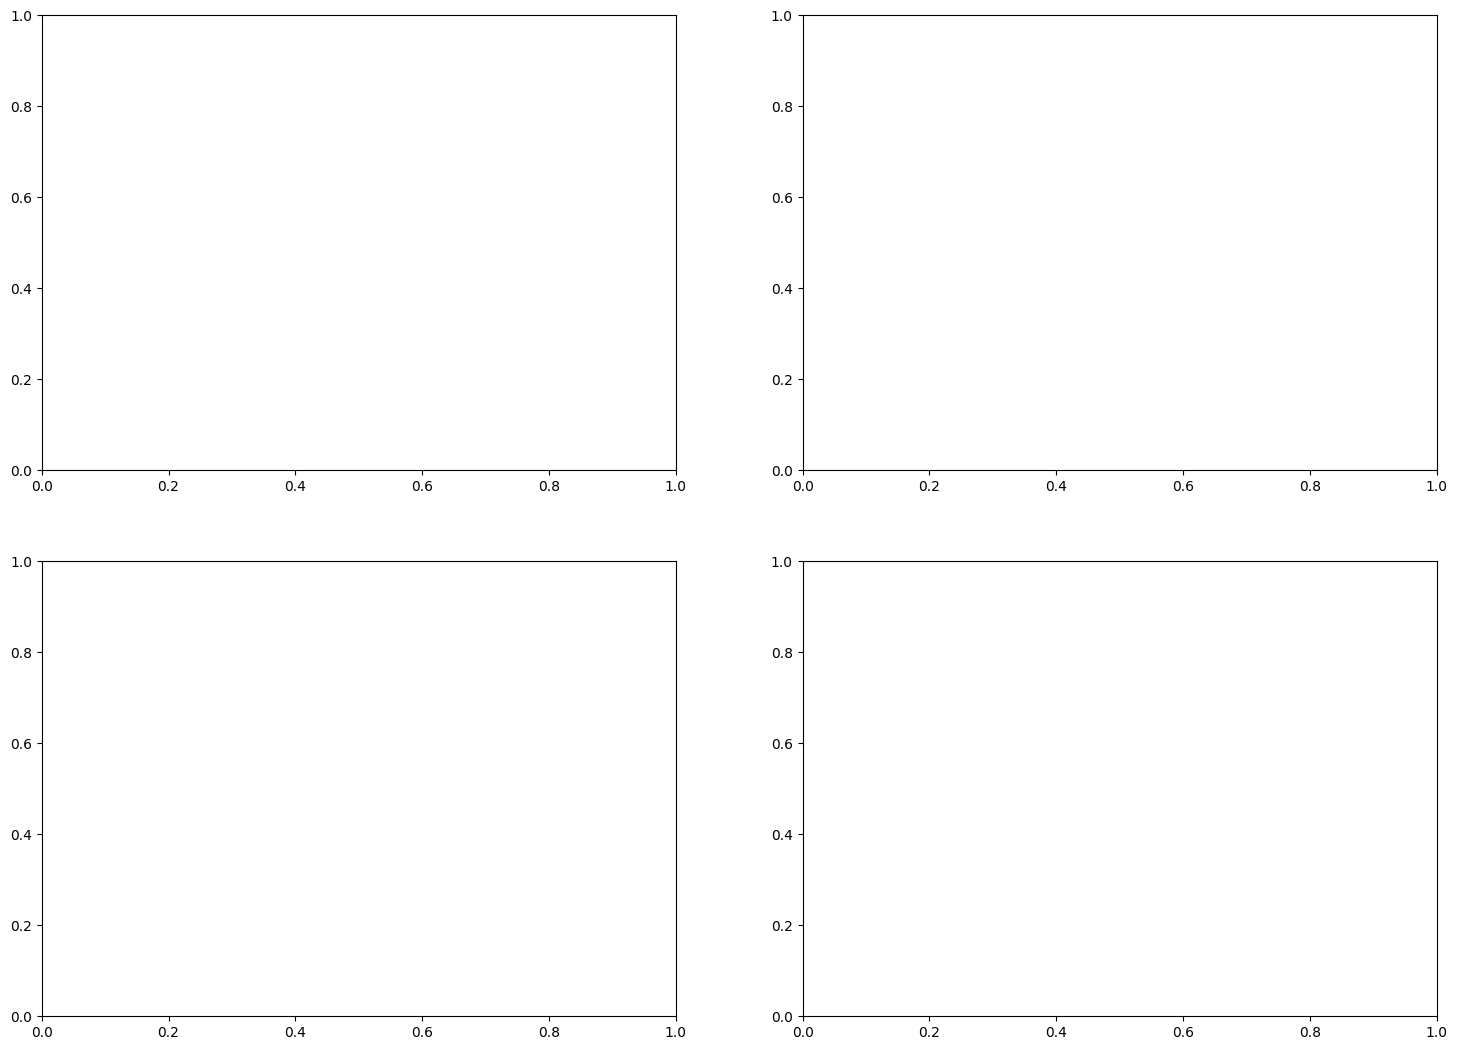

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))